In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

First, download the [GPD sample metadata](https://ftp.ebi.ac.uk/pub/databases/metagenomics/genome_sets/gut_phage_database/GutMetagenomes_metadata.csv) CSV file and save it in `data/` directory.

Only samples with >50M reads were used to assess prevalence of ≥50% complete SPMP and reference vOTUs.

In [2]:
df_gpd = pd.read_csv('../data/GutMetagenomes_metadata.csv', nrows=28060, index_col=False).rename(columns={'run': 'sample_id'})

df_gpd50m = df_gpd[df_gpd.read_count > 50e6]

num_samples_gpd = len(df_gpd50m)

# continent-level

df_gpd50m_c = df_gpd50m.groupby('continent', as_index=False).agg(num_samples_c = ('sample_id', 'count'))

C:\Users\chenhr\AppData\Local\Temp\ipykernel_9316\1861791262.py:1: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df_gpd = pd.read_csv('../data/GutMetagenomes_metadata.csv', nrows=28060, index_col=False).rename(columns={'run': 'sample_id'})


In [3]:
# global VFC prevalence

df = pd.read_excel('../data/Supplementary_Data_5_SPMP_and_global_VFC_prevalence.xlsx', sheet_name='global')
df = df.merge(df_gpd50m, on='sample_id', how='left')

# group Crassvirales together ('49' used as placeholder)

df['VFC_c2'] = np.where(df.VFC.isin([49,67,117,242]), 49, df.VFC)

In [4]:
# for plotting

vfcs2plot = [*range(1,14),43,49,183]
knownvfcs = [1,13,43,49,183]
replacements = {'VFC 49': 'Crassvirales', 'VFC 183': 'Flandersviridae', 'VFC 43': 'Konodaiviridae', 'VFC 13': 'Tsurumiviridae', 'VFC 1': 'Heliusvirales'}
italic_labels = {'Crassvirales', 'Flandersviridae', 'Konodaiviridae', 'Tsurumiviridae', 'Heliusvirales'}
color_dict = {'known': 'C0', 'novel': 'C3'}

### Fig. 1F: global VFC prevalence

In [5]:
df_global = df.groupby('VFC_c2', as_index=False).agg(num_samples = ('sample_id', 'count'), median_perc_abun = ('perc_abun', 'median')).sort_values('num_samples', ascending=False)
df_global['perc_prevalence'] = df_global['num_samples']/num_samples_gpd*100

df_global = df_global[df_global.VFC_c2.isin(vfcs2plot)].copy()
df_global['vctype'] = np.where(df_global.VFC_c2.isin(knownvfcs), 'known', 'novel')

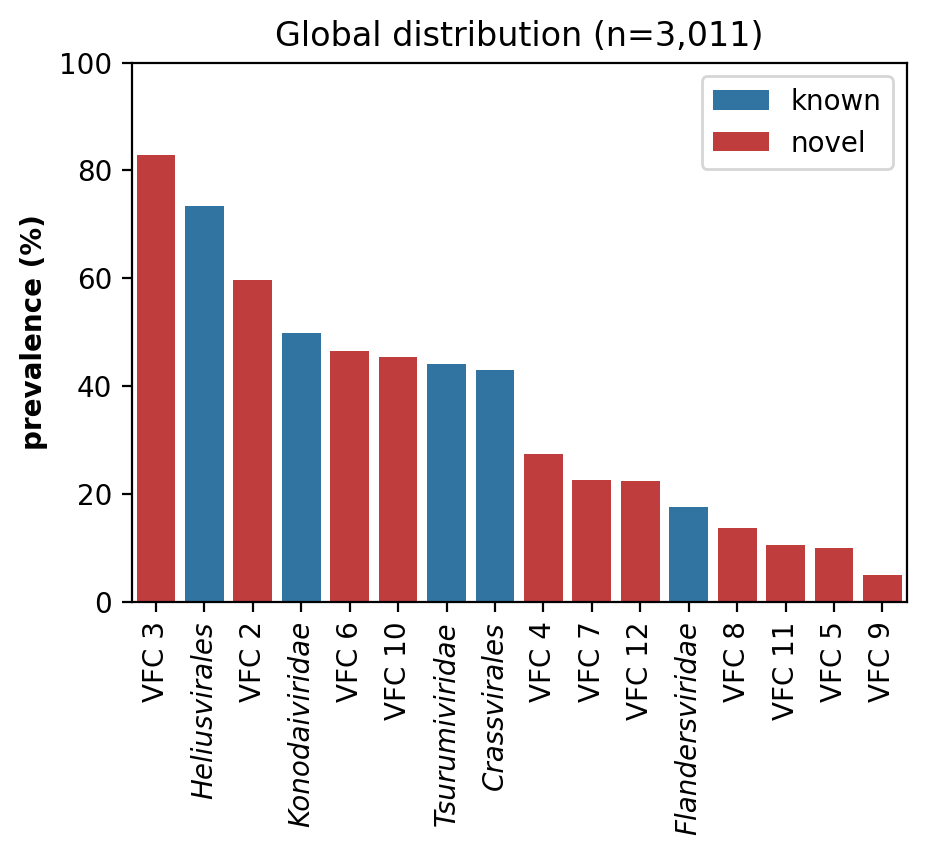

In [6]:
sortedvfcs = df_global.VFC_c2.tolist()
sortedvfcs1 = [replacements.get(f'VFC {int(vfc)}', f'VFC {int(vfc)}') for vfc in sortedvfcs]

fig, ax = plt.subplots(figsize=(5,3.5), dpi=200)

sns.barplot(data=df_global, x='VFC_c2', y='perc_prevalence', hue='vctype', order=sortedvfcs, palette=color_dict, ax=ax)

plt.title(f'Global distribution (n={num_samples_gpd:,})')
plt.xticks(range(len(sortedvfcs1)), sortedvfcs1, rotation=90)
plt.xlabel('')
plt.ylabel('prevalence (%)', weight='bold')
plt.ylim(0,100)

for tick in ax.get_xticklabels():
    if tick.get_text() in italic_labels:
        tick.set_fontstyle('italic')

ax.legend(title='')

### Supplementary Fig. 10: global VFC prevalence by continent

In [7]:
df_cont = df.groupby(['VFC_c2','continent'], as_index=False).agg({'sample_id': 'count'}).sort_values('sample_id', ascending=False)
df_cont = df_cont.merge(df_gpd50m_c, on='continent', how='left')
df_cont['perc_prevalence'] = df_cont['sample_id']/df_cont.num_samples_c*100

Asia

In [8]:
c = 'Asia'

df_cont1 = df_cont[df_cont.continent == c]
df_cont1 = df_cont1[df_cont1.VFC_c2.isin(vfcs2plot)]
df_cont1['vctype'] = np.where(df_cont1.VFC_c2.isin(knownvfcs), 'known', 'novel')

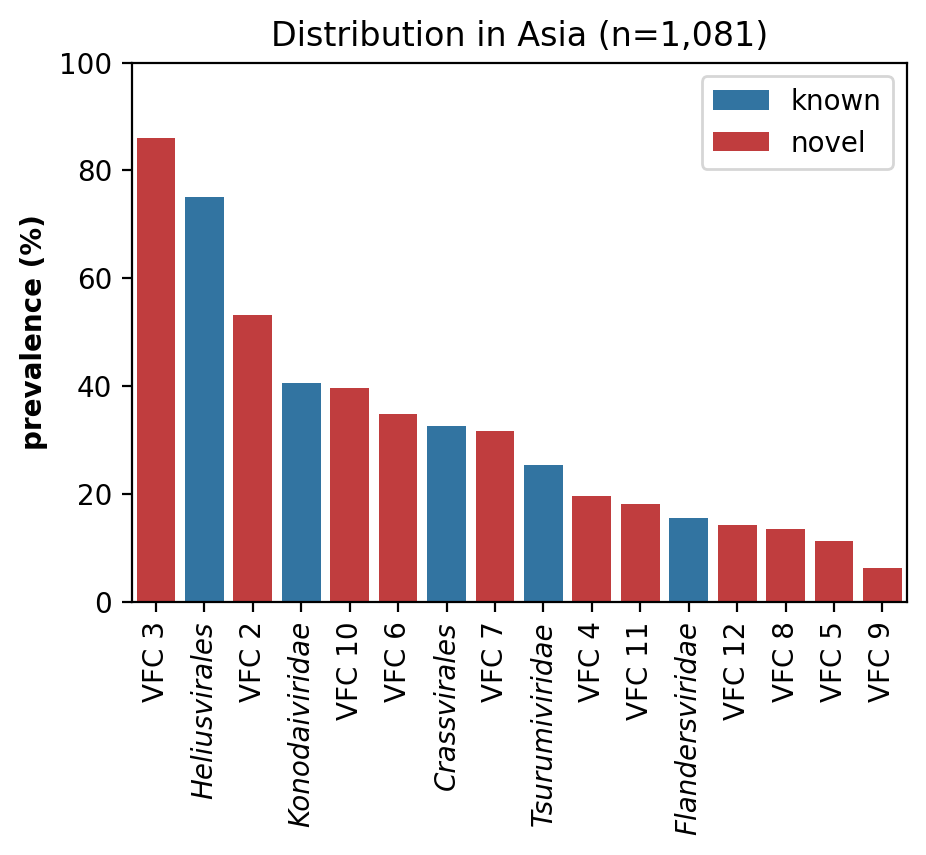

In [9]:
sortedvfcs = df_cont1.VFC_c2.tolist()
sortedvfcs1 = [replacements.get(f'VFC {int(vfc)}', f'VFC {int(vfc)}') for vfc in sortedvfcs]

fig, ax = plt.subplots(figsize=(5,3.5), dpi=200)

sns.barplot(data=df_cont1, x='VFC_c2', y='perc_prevalence', hue='vctype', order=sortedvfcs, palette=color_dict, ax=ax)

plt.title(f'Distribution in {c} (n={df_cont1.num_samples_c.iloc[0]:,})')
plt.xticks(range(len(sortedvfcs1)), sortedvfcs1, rotation=90)
plt.xlabel('')
plt.ylabel('prevalence (%)', weight='bold')
plt.ylim(0,100)

for tick in ax.get_xticklabels():
    if tick.get_text() in italic_labels:
        tick.set_fontstyle('italic')

ax.legend(title='')

Europe

In [10]:
c = 'Europe'

df_cont1 = df_cont[df_cont.continent == c]
df_cont1 = df_cont1[df_cont1.VFC_c2.isin(vfcs2plot)]
df_cont1['vctype'] = np.where(df_cont1.VFC_c2.isin(knownvfcs), 'known', 'novel')

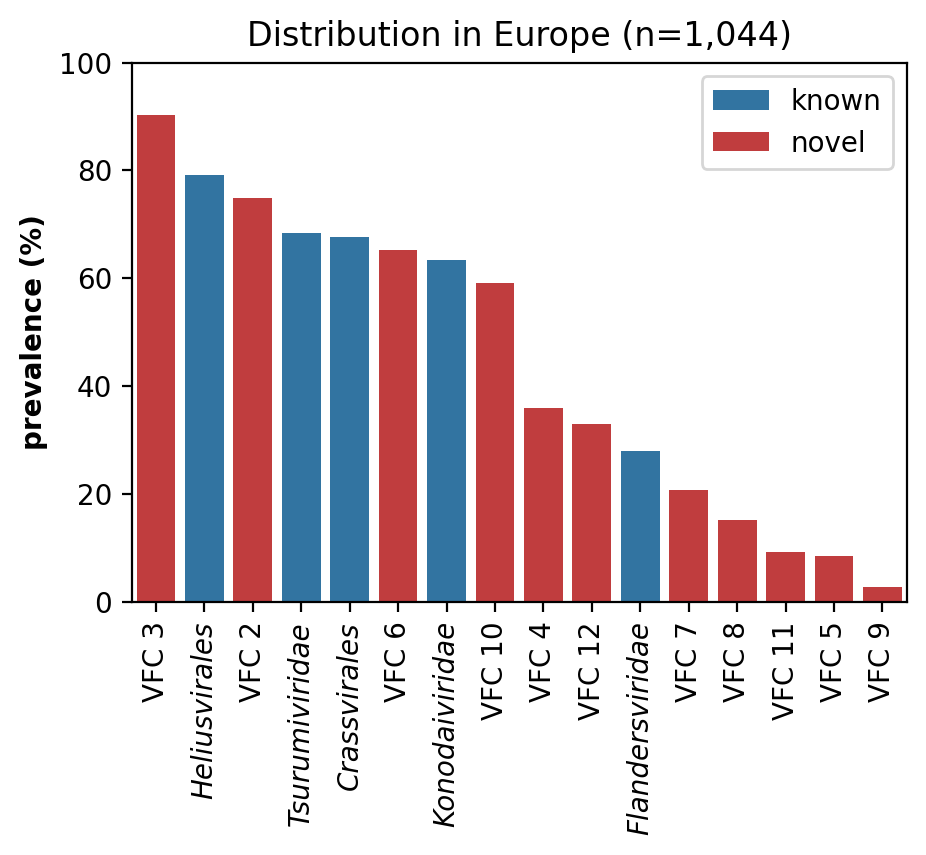

In [11]:
sortedvfcs = df_cont1.VFC_c2.tolist()
sortedvfcs1 = [replacements.get(f'VFC {int(vfc)}', f'VFC {int(vfc)}') for vfc in sortedvfcs]

fig, ax = plt.subplots(figsize=(5,3.5), dpi=200)

sns.barplot(data=df_cont1, x='VFC_c2', y='perc_prevalence', hue='vctype', order=sortedvfcs, palette=color_dict, ax=ax)

plt.title(f'Distribution in {c} (n={df_cont1.num_samples_c.iloc[0]:,})')
plt.xticks(range(len(sortedvfcs1)), sortedvfcs1, rotation=90)
plt.xlabel('')
plt.ylabel('prevalence (%)', weight='bold')
plt.ylim(0,100)

for tick in ax.get_xticklabels():
    if tick.get_text() in italic_labels:
        tick.set_fontstyle('italic')

ax.legend(title='')

North America

In [12]:
c = 'North America'

df_cont1 = df_cont[df_cont.continent == c]
df_cont1 = df_cont1[df_cont1.VFC_c2.isin(vfcs2plot)]
df_cont1['vctype'] = np.where(df_cont1.VFC_c2.isin(knownvfcs), 'known', 'novel')

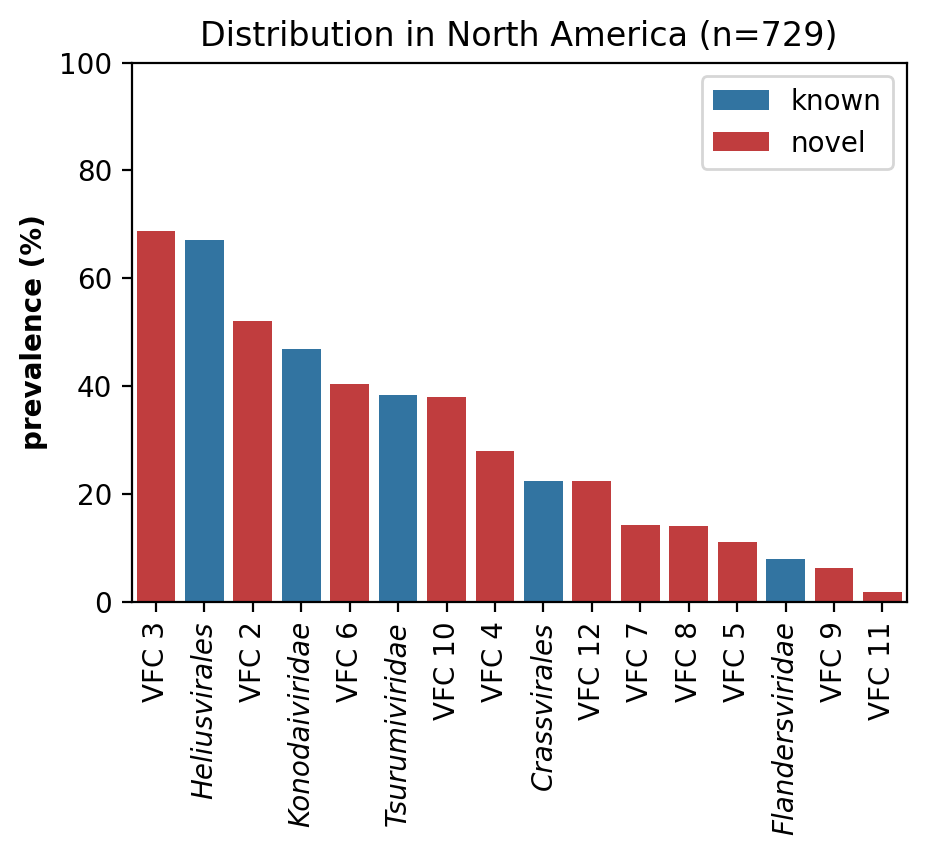

In [13]:
sortedvfcs = df_cont1.VFC_c2.tolist()
sortedvfcs1 = [replacements.get(f'VFC {int(vfc)}', f'VFC {int(vfc)}') for vfc in sortedvfcs]

fig, ax = plt.subplots(figsize=(5,3.5), dpi=200)

sns.barplot(data=df_cont1, x='VFC_c2', y='perc_prevalence', hue='vctype', order=sortedvfcs, palette=color_dict, ax=ax)

plt.title(f'Distribution in {c} (n={df_cont1.num_samples_c.iloc[0]:,})')
plt.xticks(range(len(sortedvfcs1)), sortedvfcs1, rotation=90)
plt.xlabel('')
plt.ylabel('prevalence (%)', weight='bold')
plt.ylim(0,100)

for tick in ax.get_xticklabels():
    if tick.get_text() in italic_labels:
        tick.set_fontstyle('italic')

ax.legend(title='')

### Supplementary Fig. 12: global prevalence vs. median abundance of top VFCs

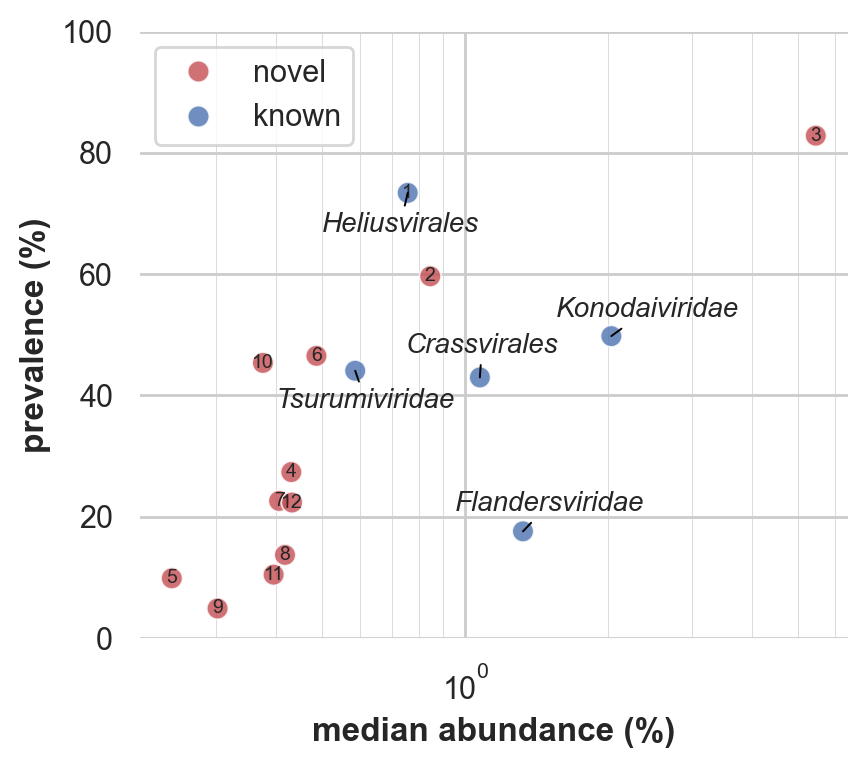

In [14]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(4.5,4), dpi=200)

g = sns.scatterplot(
    data=df_global,
    x='median_perc_abun', y='perc_prevalence',
    hue='vctype',
    marker='o',
    palette=color_dict,
    s=60, alpha=0.8, ax=ax
)
g.set(xscale="log")
plt.ylim(0,100)

g.xaxis.grid(True, "minor", linewidth=.25)
plt.xlabel('median abundance (%)', weight='bold')
plt.ylabel('prevalence (%)', weight='bold')

ax.legend(title='', loc='upper left')

for i in [*range(1,13)]:
    ax.annotate(str(i), xy=(df_global.loc[df_global.VFC_c2 == i, 'median_perc_abun'].iloc[0], df_global.loc[df_global.VFC_c2 == i, 'perc_prevalence'].iloc[0]), ha='center', va='center', fontsize=7)

ax.annotate('Crassvirales', xy=(1.073562, 42.975756), xytext=(0.75, 47), fontsize=10, fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.7)
            )
ax.annotate('Heliusvirales', xy=(0.757022, 73.397542), xytext=(0.5, 67), fontsize=10, fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.7)
            )
ax.annotate('Konodaiviridae', xy=(2.028444, 49.784125), xytext=(1.55, 53), fontsize=10, fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.7)
            )
ax.annotate('Tsurumiviridae', xy=(0.587139, 44.071737), xytext=(0.4, 38), fontsize=10, fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.7)
            )
ax.annotate('Flandersviridae', xy=(1.322623, 17.602126), xytext=(0.95, 21), fontsize=10, fontstyle='italic',
            arrowprops=dict(arrowstyle='-', color='black', relpos=(0.5,0.5), shrinkA=0, shrinkB=0, linewidth=0.7)
            )

sns.despine(left=True, bottom=True)
plt.tight_layout()